# Autocomplete and Autocorrect System

## Project Overview

This project focuses on building a simple NLP-based system for predicting the next word and correcting misspelled words.

A Shakespeare text corpus is used as the source of language data. The text is cleaned and processed to create a vocabulary and word sequences.

The project uses n-gram language modeling for autocomplete and edit distance for autocorrect.

## Objectives

- Prepare and clean a large text corpus
- Analyze word frequencies
- Build bigram and trigram models
- Predict the next word for a given input
- Implement an autocomplete system
- Detect and correct common spelling mistakes
- Test the system with sample inputs
- Evaluate the performance of the predictions

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Regular Expressions
- Jupyter Notebook
- Natural Language Processing

In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
dataset_path = "../dataset/FolgerDigitalTexts_TXT_Complete"

files = [
    file for file in os.listdir(dataset_path)
    if os.path.isfile(os.path.join(dataset_path, file))
]

print("Number of text files:", len(files))
print("Files:", files[:10])

Number of text files: 42
Files: ['1H4.txt', '1H6.txt', '2H4.txt', '2H6.txt', '3H6.txt', 'Ado.txt', 'Ant.txt', 'AWW.txt', 'AYL.txt', 'Cor.txt']


In [3]:
all_text = []

for file in files:
    path = os.path.join(dataset_path, file)
    
    with open(path, "r", encoding="utf-8") as f:
        all_text.append(f.read())

corpus = "\n".join(all_text)

print("Total characters:", len(corpus))
print("\nSample:")
print(corpus[:1000])

Total characters: 5327622

Sample:
Henry IV, Part I
by William Shakespeare
Edited by Barbara A. Mowat and Paul Werstine
  with Michael Poston and Rebecca Niles
Folger Shakespeare Library
http://www.folgerdigitaltexts.org/?chapter=5&play=1H4
Created on Jul 31, 2015, from FDT version 0.9.2

Characters in the Play
KING HENRY IV, formerly Henry Bolingbroke
PRINCE HAL, Prince of Wales and heir to the throne (also called Harry and Harry Monmouth)
LORD JOHN OF LANCASTER, younger son of King Henry
EARL OF WESTMORELAND
SIR WALTER BLUNT
HOTSPUR (Sir Henry, or Harry, Percy)
LADY PERCY (also called Kate)
EARL OF NORTHUMBERLAND, Henry Percy, Hotspur's father
EARL OF WORCESTER, Thomas Percy, Hotspur's uncle
EDMUND MORTIMER, earl of March
LADY MORTIMER (also called "the Welsh lady")
OWEN GLENDOWER, a Welsh lord, father of Lady Mortimer
DOUGLAS (Archibald, earl of Douglas)
ARCHBISHOP (Richard Scroop, archbishop of York)
SIR MICHAEL, a priest or knight associated with the archbishop
SIR RICHARD VERNON,

In [4]:
corpus = corpus.lower()

corpus = re.sub(r"[^a-z\s]", " ", corpus)
corpus = re.sub(r"\s+", " ", corpus).strip()

print(corpus[:1000])

henry iv part i by william shakespeare edited by barbara a mowat and paul werstine with michael poston and rebecca niles folger shakespeare library http www folgerdigitaltexts org chapter play h created on jul from fdt version characters in the play king henry iv formerly henry bolingbroke prince hal prince of wales and heir to the throne also called harry and harry monmouth lord john of lancaster younger son of king henry earl of westmoreland sir walter blunt hotspur sir henry or harry percy lady percy also called kate earl of northumberland henry percy hotspur s father earl of worcester thomas percy hotspur s uncle edmund mortimer earl of march lady mortimer also called the welsh lady owen glendower a welsh lord father of lady mortimer douglas archibald earl of douglas archbishop richard scroop archbishop of york sir michael a priest or knight associated with the archbishop sir richard vernon an english knight sir john falstaff poins also called edward yedward and ned bardolph peto g

In [5]:
words = corpus.split()

print("Total words:", len(words))
print("Unique words:", len(set(words)))

print("\nFirst 30 words:")
print(words[:30])

Total words: 979188
Unique words: 24502

First 30 words:
['henry', 'iv', 'part', 'i', 'by', 'william', 'shakespeare', 'edited', 'by', 'barbara', 'a', 'mowat', 'and', 'paul', 'werstine', 'with', 'michael', 'poston', 'and', 'rebecca', 'niles', 'folger', 'shakespeare', 'library', 'http', 'www', 'folgerdigitaltexts', 'org', 'chapter', 'play']


In [6]:
word_counts = Counter(words)

common_words = word_counts.most_common(20)

for word, count in common_words:
    print(f"{word}: {count}")

the: 29336
and: 28462
i: 23677
to: 21973
of: 18439
a: 15848
you: 14963
my: 13122
that: 12186
in: 11995
is: 9895
not: 9011
with: 8625
he: 8455
s: 8382
me: 8222
it: 8174
for: 8152
his: 7651
be: 7334


In [7]:
bigrams = list(zip(words[:-1], words[1:]))

print("Total bigrams:", len(bigrams))
print("Sample bigrams:")
print(bigrams[:20])

Total bigrams: 979187
Sample bigrams:
[('henry', 'iv'), ('iv', 'part'), ('part', 'i'), ('i', 'by'), ('by', 'william'), ('william', 'shakespeare'), ('shakespeare', 'edited'), ('edited', 'by'), ('by', 'barbara'), ('barbara', 'a'), ('a', 'mowat'), ('mowat', 'and'), ('and', 'paul'), ('paul', 'werstine'), ('werstine', 'with'), ('with', 'michael'), ('michael', 'poston'), ('poston', 'and'), ('and', 'rebecca'), ('rebecca', 'niles')]


In [8]:
bigram_counts = Counter(bigrams)

print("Most common bigrams:")

for pair, count in bigram_counts.most_common(20):
    print(pair, ":", count)

Most common bigrams:
('i', 'am') : 1967
('i', 'll') : 1889
('in', 'the') : 1745
('i', 'have') : 1719
('my', 'lord') : 1693
('i', 'will') : 1631
('to', 'the') : 1539
('of', 'the') : 1502
('it', 'is') : 1118
('to', 'be') : 1046
('that', 'i') : 998
('and', 'i') : 881
('the', 'king') : 865
('and', 'the') : 865
('i', 'do') : 856
('you', 'are') : 753
('of', 'my') : 749
('is', 'the') : 702
('i', 'would') : 701
('you', 'have') : 680


In [9]:
trigrams = list(zip(words[:-2], words[1:-1], words[2:]))

print("Total trigrams:", len(trigrams))
print("Sample trigrams:")
print(trigrams[:20])

Total trigrams: 979186
Sample trigrams:
[('henry', 'iv', 'part'), ('iv', 'part', 'i'), ('part', 'i', 'by'), ('i', 'by', 'william'), ('by', 'william', 'shakespeare'), ('william', 'shakespeare', 'edited'), ('shakespeare', 'edited', 'by'), ('edited', 'by', 'barbara'), ('by', 'barbara', 'a'), ('barbara', 'a', 'mowat'), ('a', 'mowat', 'and'), ('mowat', 'and', 'paul'), ('and', 'paul', 'werstine'), ('paul', 'werstine', 'with'), ('werstine', 'with', 'michael'), ('with', 'michael', 'poston'), ('michael', 'poston', 'and'), ('poston', 'and', 'rebecca'), ('and', 'rebecca', 'niles'), ('rebecca', 'niles', 'folger')]


In [10]:
trigram_counts = Counter(trigrams)

print("Most common trigrams:")

for group, count in trigram_counts.most_common(20):
    print(group, ":", count)

Most common trigrams:
('they', 'exit', 'scene') : 387
('exit', 'scene', 'enter') : 336
('i', 'pray', 'you') : 253
('i', 'will', 'not') : 230
('i', 'know', 'not') : 170
('i', 'do', 'not') : 164
('act', 'scene', 'enter') : 151
('i', 'am', 'a') : 147
('i', 'am', 'not') : 146
('the', 'duke', 'of') : 140
('i', 'll', 'be') : 136
('my', 'lord', 'i') : 136
('and', 'i', 'will') : 135
('my', 'good', 'lord') : 133
('the', 'king', 's') : 127
('i', 'would', 'not') : 127
('it', 'is', 'a') : 124
('this', 'is', 'the') : 123
('there', 'is', 'no') : 122
('duke', 'as', 'friar') : 122


In [11]:
next_word = {}

for (first, second), count in bigram_counts.items():
    if first not in next_word:
        next_word[first] = []
    next_word[first].append((second, count))

next_two_words = {}

for (first, second, third), count in trigram_counts.items():
    key = (first, second)
    
    if key not in next_two_words:
        next_two_words[key] = []
    
    next_two_words[key].append((third, count))

for key in next_word:
    next_word[key].sort(key=lambda x: x[1], reverse=True)

for key in next_two_words:
    next_two_words[key].sort(key=lambda x: x[1], reverse=True)

print("Autocomplete dictionaries created.")

Autocomplete dictionaries created.


In [12]:
def autocomplete(text, number=3):
    entered_words = re.findall(r"[a-z]+", text.lower())
    
    if not entered_words:
        return []
    
    if len(entered_words) >= 2:
        pair = tuple(entered_words[-2:])
        
        if pair in next_two_words:
            return [word for word, count in next_two_words[pair][:number]]
    
    last_word = entered_words[-1]
    
    if last_word in next_word:
        return [word for word, count in next_word[last_word][:number]]
    
    return []

In [13]:
test_inputs = [
    "to",
    "the",
    "i am",
    "my lord",
    "shall"
]

for text in test_inputs:
    predictions = autocomplete(text)
    print(f"{text} -> {predictions}")

to -> ['the', 'be', 'my']
the -> ['king', 'world', 'duke']
i am -> ['a', 'not', 'sure']
my lord -> ['i', 'of', 'and']
shall -> ['be', 'i', 'not']


In [14]:
examples = [
    "good",
    "what",
    "this",
    "love",
    "when"
]

for text in examples:
    print(text, "->", autocomplete(text, 5))

good -> ['lord', 'my', 'morrow', 'night', 'sir']
what -> ['is', 's', 'i', 'a', 'you']
this -> ['is', 'day', 'i', 'the', 'night']
love -> ['and', 's', 'i', 'to', 'thee']
when -> ['i', 'he', 'you', 'the', 'thou']


In [15]:
frequency_data = pd.DataFrame(
    word_counts.most_common(20),
    columns=["Word", "Frequency"]
)

display(frequency_data)

,Word,Frequency
0,the,29336
1,and,28462
2,i,23677
3,to,21973
4,of,18439
5,a,15848
6,you,14963
7,my,13122
8,that,12186
9,in,11995


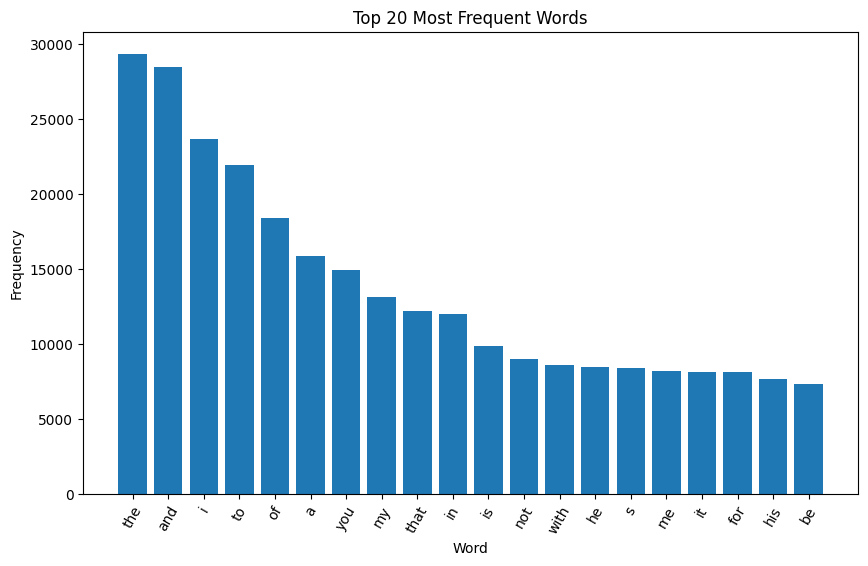

In [16]:
plt.figure(figsize=(10, 6))

plt.bar(
    frequency_data["Word"],
    frequency_data["Frequency"]
)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=60)
plt.show()

In [17]:
vocabulary = set(words)

print("Vocabulary size:", len(vocabulary))
print("Sample words:", list(vocabulary)[:20])

Vocabulary size: 24502
Sample words: ['younker', 'regiments', 'darkened', 'pleasure', 'supplies', 'incessantly', 'contained', 'mutability', 'breeders', 'preferreth', 'albany', 'stigmatical', 'zodiacs', 'revived', 'pharamond', 'ditched', 'actium', 'fervor', 'thrived', 'journey']


In [18]:
def edit_distance(word1, word2):
    rows = len(word1) + 1
    cols = len(word2) + 1
    
    distance = [[0] * cols for _ in range(rows)]
    
    for i in range(rows):
        distance[i][0] = i
    
    for j in range(cols):
        distance[0][j] = j
    
    for i in range(1, rows):
        for j in range(1, cols):
            if word1[i - 1] == word2[j - 1]:
                distance[i][j] = distance[i - 1][j - 1]
            else:
                distance[i][j] = 1 + min(
                    distance[i - 1][j],
                    distance[i][j - 1],
                    distance[i - 1][j - 1]
                )
    
    return distance[-1][-1]

In [19]:
print("Distance:", edit_distance("becaus", "because"))
print("Distance:", edit_distance("frend", "friend"))
print("Distance:", edit_distance("beautifull", "beautiful"))

Distance: 1
Distance: 1
Distance: 1


In [20]:
def autocorrect(word, max_distance=2):
    word = word.lower()
    
    candidates = [
        item for item in vocabulary
        if abs(len(item) - len(word)) <= max_distance
    ]
    
    matches = []
    
    for candidate in candidates:
        distance = edit_distance(word, candidate)
        
        if distance <= max_distance:
            matches.append((candidate, distance, word_counts[candidate]))
    
    if not matches:
        return None
    
    matches.sort(key=lambda x: (x[1], -x[2]))
    
    return matches[0][0]

In [21]:
misspelled_words = [
    "becaus",
    "frend",
    "beautifull",
    "somthing",
    "thouh"
]

for word in misspelled_words:
    corrected = autocorrect(word)
    print(f"{word} -> {corrected}")

becaus -> because
frend -> friend
beautifull -> beautiful
somthing -> something
thouh -> thou


In [22]:
corrected_results = []

for word in misspelled_words:
    corrected = autocorrect(word)
    corrected_results.append([word, corrected])

autocorrect_data = pd.DataFrame(
    corrected_results,
    columns=["Misspelled Word", "Suggested Correction"]
)

display(autocorrect_data)

,Misspelled Word,Suggested Correction
0,becaus,because
1,frend,friend
2,beautifull,beautiful
3,somthing,something
4,thouh,thou


In [23]:
print("Autocomplete Tests")
print("------------------")

for text in ["to", "the", "my lord", "i am", "shall"]:
    print(text, "->", autocomplete(text, 5))

print("\nAutocorrect Tests")
print("-----------------")

for word in misspelled_words:
    print(word, "->", autocorrect(word))

Autocomplete Tests
------------------
to -> ['the', 'be', 'my', 'me', 'you']
the -> ['king', 'world', 'duke', 'gods', 'time']
my lord -> ['i', 'of', 'and', 'hamlet', 'the']
i am -> ['a', 'not', 'sure', 'glad', 'the']
shall -> ['be', 'i', 'not', 'have', 'we']

Autocorrect Tests
-----------------
becaus -> because
frend -> friend
beautifull -> beautiful
somthing -> something
thouh -> thou


In [24]:
test_pairs = list(bigram_counts.most_common(20))

correct = 0

for (first, second), count in test_pairs:
    predictions = autocomplete(first, 3)
    
    if second in predictions:
        correct += 1

accuracy = correct / len(test_pairs) * 100

print("Autocomplete Top-3 Accuracy:", round(accuracy, 2), "%")

Autocomplete Top-3 Accuracy: 85.0 %


In [26]:
test_words = [
    word for word in vocabulary
    if len(word) >= 5
]

test_words = sorted(
    test_words,
    key=lambda word: word_counts[word],
    reverse=True
)[:30]

correct = 0
results = []

for word in test_words:
    typo = word[:2] + word[3:]
    prediction = autocorrect(typo)
    
    if prediction == word:
        correct += 1
    
    results.append([word, typo, prediction])

if test_words:
    autocorrect_accuracy = correct / len(test_words) * 100
    print("Autocorrect Accuracy:", round(autocorrect_accuracy, 2), "%")
else:
    print("No suitable test words found.")

Autocorrect Accuracy: 66.67 %


In [27]:
evaluation_data = pd.DataFrame(
    results,
    columns=["Original Word", "Generated Typo", "Predicted Word"]
)

display(evaluation_data)

,Original Word,Generated Typo,Predicted Word
0,shall,shll,shall
1,which,whch,which
2,enter,ener,enter
3,would,wold,wold
4,their,thir,this
5,there,thre,the
6,should,shuld,should
7,where,whre,were
8,these,thse,the
9,first,fist,fist


In [29]:
evaluation_summary = pd.DataFrame({
    "System": ["Autocomplete", "Autocorrect"],
    "Metric": ["Top-3 Accuracy", "Accuracy"],
    "Score": [accuracy, autocorrect_accuracy]
})

display(evaluation_summary)

,System,Metric,Score
0,Autocomplete,Top-3 Accuracy,85.000000
1,Autocorrect,Accuracy,66.666667


In [30]:
frequency_data.to_csv("../output/word_frequency.csv", index=False)

autocorrect_data.to_csv("../output/autocorrect_results.csv", index=False)

evaluation_data.to_csv("../output/autocorrect_evaluation.csv", index=False)

evaluation_summary.to_csv("../output/evaluation_summary.csv", index=False)

print("Output files saved successfully.")

Output files saved successfully.


In [31]:
print("Autocomplete Top-3 Accuracy:", round(accuracy, 2), "%")
print("Autocorrect Accuracy:", round(autocorrect_accuracy, 2), "%")
print("Vocabulary Size:", len(vocabulary))
print("Total Words:", len(words))

Autocomplete Top-3 Accuracy: 85.0 %
Autocorrect Accuracy: 66.67 %
Vocabulary Size: 24502
Total Words: 979188


## Key Insights

- The Shakespeare corpus contains a large vocabulary with many unique words.
- Word frequency analysis shows that common English words occur most frequently.
- Bigram and trigram models can predict likely next words based on previous words.
- The autocomplete system provides context-based word suggestions.
- Edit distance helps identify words that are similar to misspelled inputs.
- Word frequency is used to select the most suitable correction when multiple words have similar edit distances.
- The evaluation results show how effectively the system performs autocomplete and autocorrect tasks.

## Conclusion

An NLP-based autocomplete and autocorrect system was developed using the Folger Shakespeare text corpus.

The project used word frequency analysis, bigrams and trigrams for autocomplete, and edit distance for autocorrect. The system was tested with sample inputs and evaluated using accuracy measures.

The project demonstrates how basic NLP techniques can be used to build practical text prediction and spelling correction systems.

In [32]:
print("Final Project Results")
print("---------------------")
print("Total Words:", len(words))
print("Vocabulary Size:", len(vocabulary))
print("Autocomplete Top-3 Accuracy:", round(accuracy, 2), "%")
print("Autocorrect Accuracy:", round(autocorrect_accuracy, 2), "%")

Final Project Results
---------------------
Total Words: 979188
Vocabulary Size: 24502
Autocomplete Top-3 Accuracy: 85.0 %
Autocorrect Accuracy: 66.67 %


## Final Summary

The project successfully implemented both autocomplete and autocorrect functionality using NLP techniques.

The autocomplete system uses bigram and trigram language models to predict possible next words. The autocorrect system uses edit distance and word frequency to suggest corrections for misspelled words.

The system was tested and evaluated using sample inputs, and the results were saved as CSV files for further analysis.